<a href="https://colab.research.google.com/github/Henvitha26/Henvitha26/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import random
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.layers import (Conv2D, GlobalAveragePooling2D, Dense, Dropout,
                                     BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')


               PNEUMONIA DETECTION FROM CHEST X-RAYS
            ResNet50 + CBAM Attention + Grad-CAM


In [24]:
print("\n" + "="*70)
print("STEP 1: DOWNLOADING DATASET")
print("="*70)

import kagglehub
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print(f"\n✓ Dataset downloaded successfully!")
print(f"✓ Path: {path}")


print(f"\n Dataset contents:")
for item in os.listdir(path):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  {item}/")
    else:
        print(f" {item}")



STEP 1: DOWNLOADING DATASET
Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.

✓ Dataset downloaded successfully!
✓ Path: /kaggle/input/chest-xray-pneumonia

📁 Dataset contents:
   📂 chest_xray/


In [25]:
# ============================================
# STEP 2: EXPLORE DATASET STRUCTURE
# ============================================
print("\n" + "="*70)
print("STEP 2: EXPLORING DATASET STRUCTURE")
print("="*70)

# The dataset might have a subfolder
data_path = path
if 'chest_xray' in os.listdir(path):
    data_path = os.path.join(path, 'chest_xray')
    print(f"✓ Found 'chest_xray' subfolder: {data_path}")
elif 'chest-xray-pneumonia' in os.listdir(path):
    data_path = os.path.join(path, 'chest-xray-pneumonia')
    print(f"✓ Found 'chest-xray-pneumonia' subfolder: {data_path}")


train_path = os.path.join(data_path, 'train')
val_path = os.path.join(data_path, 'val')
test_path = os.path.join(data_path, 'test')

if not os.path.exists(train_path):
    train_path = os.path.join(path, 'train')
    val_path = os.path.join(path, 'val')
    test_path = os.path.join(path, 'test')

print(f"\n  Data splits:")
print(f"   Train: {train_path} → Exists: {os.path.exists(train_path)}")
print(f"   Val:   {val_path} → Exists: {os.path.exists(val_path)}")
print(f"   Test:  {test_path} → Exists: {os.path.exists(test_path)}")


STEP 2: EXPLORING DATASET STRUCTURE
✓ Found 'chest_xray' subfolder: /kaggle/input/chest-xray-pneumonia/chest_xray

📁 Data splits:
   Train: /kaggle/input/chest-xray-pneumonia/chest_xray/train → Exists: True
   Val:   /kaggle/input/chest-xray-pneumonia/chest_xray/val → Exists: True
   Test:  /kaggle/input/chest-xray-pneumonia/chest_xray/test → Exists: True


In [26]:

print("STEP 3: COUNTING IMAGES PER CLASS")


stats = {}
for split_name, split_path in [('TRAIN', train_path), ('VALIDATION', val_path), ('TEST', test_path)]:
    if os.path.exists(split_path):
        normal_path = os.path.join(split_path, 'NORMAL')
        pneumonia_path = os.path.join(split_path, 'PNEUMONIA')

        normal_count = len(os.listdir(normal_path)) if os.path.exists(normal_path) else 0
        pneumonia_count = len(os.listdir(pneumonia_path)) if os.path.exists(pneumonia_path) else 0

        stats[split_name] = {
            'Normal': normal_count,
            'Pneumonia': pneumonia_count,
            'Total': normal_count + pneumonia_count
        }
        print(f"\n{split_name} SET:")
        print(f"    NORMAL:     {normal_count:5d} images")
        print(f"    PNEUMONIA:  {pneumonia_count:5d} images")
        print(f"   TOTAL:     {normal_count + pneumonia_count:5d} images")
    else:
        print(f"\n{split_name} SET: NOT FOUND")
        stats[split_name] = {'Normal': 0, 'Pneumonia': 0, 'Total': 0}


summary_df = pd.DataFrame(stats).T
print(summary_df.to_string())
print("-"*70)

total_images = sum([v['Total'] for v in stats.values()])
print(f"\n GRAND TOTAL: {total_images} images")

# Calculate class imbalance
train_normal = stats['TRAIN']['Normal']
train_pneumonia = stats['TRAIN']['Pneumonia']
if train_normal > 0:
    imbalance_ratio = train_pneumonia / train_normal
    print(f" CLASS IMBALANCE RATIO (Pneumonia:Normal) = {imbalance_ratio:.2f}:1")
    print(f"    This means {imbalance_ratio:.0f}x more pneumonia cases than normal")
    print(f"    Will use class weights and focal loss to handle this")


STEP 3: COUNTING IMAGES PER CLASS

TRAIN SET:
   ✓ NORMAL:      1341 images
   ✓ PNEUMONIA:   3875 images
   📊 TOTAL:      5216 images

VALIDATION SET:
   ✓ NORMAL:         8 images
   ✓ PNEUMONIA:      8 images
   📊 TOTAL:        16 images

TEST SET:
   ✓ NORMAL:       234 images
   ✓ PNEUMONIA:    390 images
   📊 TOTAL:       624 images

----------------------------------------------------------------------
📊 SUMMARY TABLE:
----------------------------------------------------------------------
            Normal  Pneumonia  Total
TRAIN         1341       3875   5216
VALIDATION       8          8     16
TEST           234        390    624
----------------------------------------------------------------------

📈 GRAND TOTAL: 5856 images
📊 CLASS IMBALANCE RATIO (Pneumonia:Normal) = 2.89:1
   → This means 3x more pneumonia cases than normal
   → Will use class weights and focal loss to handle this



STEP 4: DISPLAYING SAMPLE IMAGES
📸 Found 1341 normal images and 3875 pneumonia images
🖼️ Displaying 3 random samples from each class...
   ✓ Normal sample 1: IM-0234-0001.jpeg... (1075x1550px)
   ✓ Normal sample 2: IM-0637-0001.jpeg... (1442x1746px)
   ✓ Normal sample 3: NORMAL2-IM-0875-0001.jpeg... (1912x2094px)
   ✓ Pneumonia sample 1: person1311_virus_2257.jpeg... (904x1240px)
   ✓ Pneumonia sample 2: person443_bacteria_1926.jpeg... (872x1136px)
   ✓ Pneumonia sample 3: person580_bacteria_2389.jpeg... (584x816px)


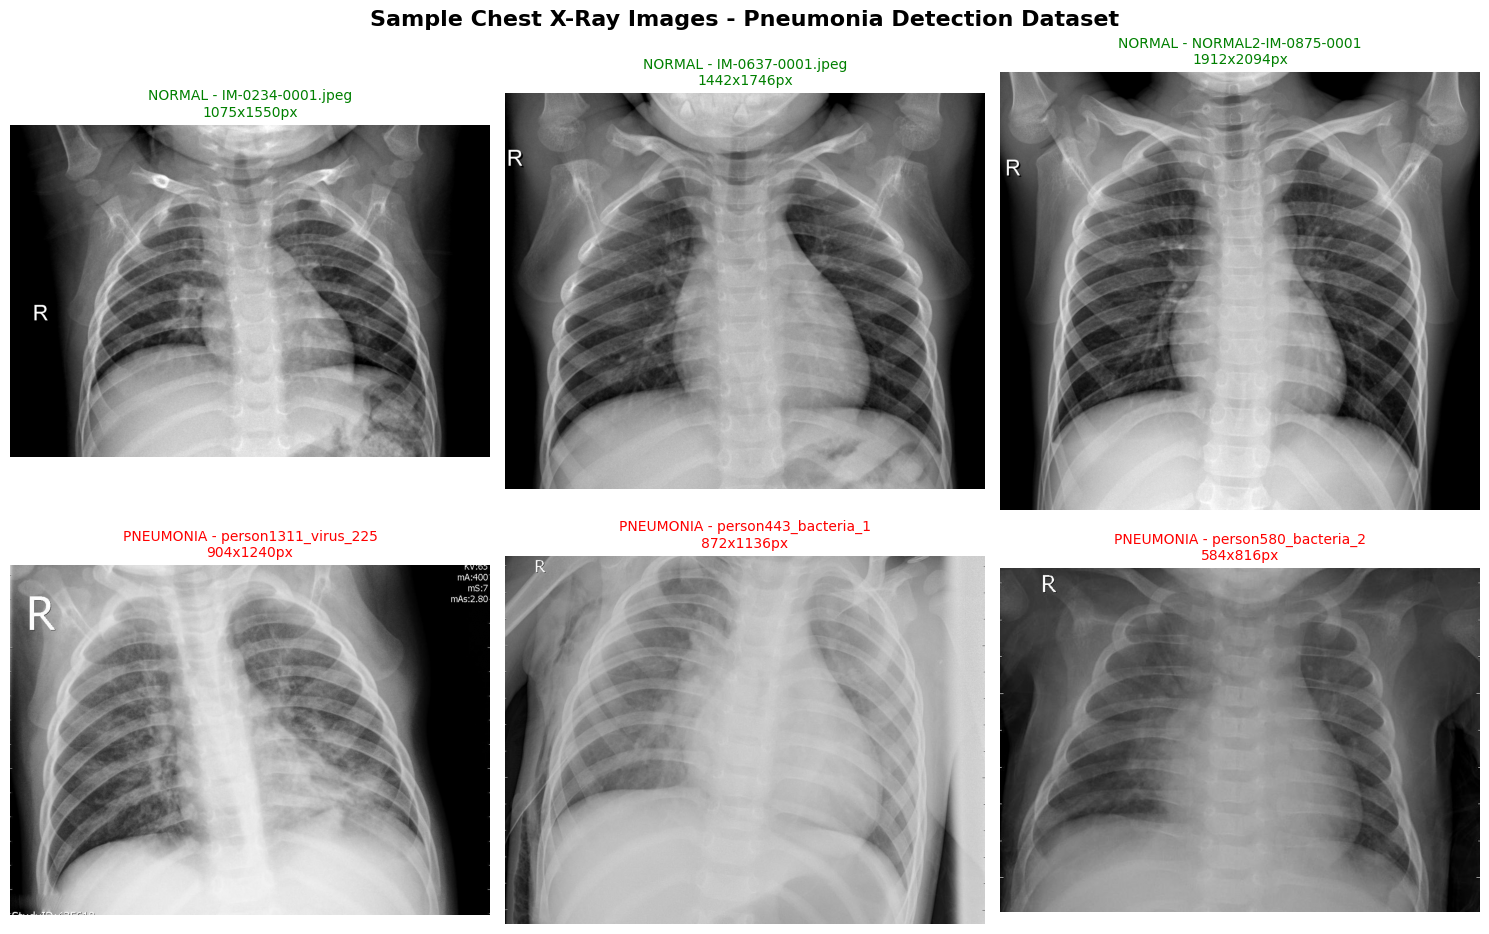


✅ Sample images saved as 'sample_chest_xrays.png'


In [27]:

# STEP 4: DISPLAY SAMPLE IMAGES

print("\n" + "="*70)
print("STEP 4: DISPLAYING SAMPLE IMAGES")
print("="*70)

def display_sample_images(train_path):
    normal_dir = os.path.join(train_path, 'NORMAL')
    pneumonia_dir = os.path.join(train_path, 'PNEUMONIA')

    if not os.path.exists(normal_dir) or not os.path.exists(pneumonia_dir):
        print(" Cannot display samples - directories not found")
        return

    normal_images = os.listdir(normal_dir)
    pneumonia_images = os.listdir(pneumonia_dir)

    print(f" Found {len(normal_images)} normal images and {len(pneumonia_images)} pneumonia images")
    print(f" Displaying 3 random samples from each class...")

    # Select random samples
    normal_samples = random.sample(normal_images, min(3, len(normal_images)))
    pneumonia_samples = random.sample(pneumonia_images, min(3, len(pneumonia_images)))

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle('Sample Chest X-Ray Images - Pneumonia Detection Dataset',
                 fontsize=16, fontweight='bold')

    # Display NORMAL images
    for i, img_file in enumerate(normal_samples):
        img_path = os.path.join(normal_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'NORMAL - {img_file[:20]}\n{img.shape[0]}x{img.shape[1]}px',
                             fontsize=10, color='green')
        axes[0, i].axis('off')
        print(f"    Normal sample {i+1}: {img_file[:30]}... ({img.shape[0]}x{img.shape[1]}px)")

    # Display PNEUMONIA images
    for i, img_file in enumerate(pneumonia_samples):
        img_path = os.path.join(pneumonia_dir, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f'PNEUMONIA - {img_file[:20]}\n{img.shape[0]}x{img.shape[1]}px',
                             fontsize=10, color='red')
        axes[1, i].axis('off')
        print(f"    Pneumonia sample {i+1}: {img_file[:30]}... ({img.shape[0]}x{img.shape[1]}px)")

    plt.tight_layout()
    plt.savefig('sample_chest_xrays.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\n Sample images saved as 'sample_chest_xrays.png'")

display_sample_images(train_path)


In [28]:

# STEP 5: DATA PREPROCESSING & AUGMENTATION

print("\n" + "="*70)
print("STEP 5: DATA PREPROCESSING & AUGMENTATION")
print("="*70)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print(f" Image Configuration:")
print(f"    Target Size: {IMG_SIZE[0]}x{IMG_SIZE[1]} pixels")
print(f"    Batch Size: {BATCH_SIZE}")
print(f"    Color Mode: RGB (converted from grayscale)")

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0,1]
    rotation_range=20,        # Random rotation
    width_shift_range=0.15,   # Horizontal shift
    height_shift_range=0.15,  # Vertical shift
    shear_range=0.1,          # Shear transformation
    zoom_range=0.15,          # Random zoom
    horizontal_flip=True,     # Horizontal flip (X-rays are symmetric)
    fill_mode='nearest',      # Fill missing pixels
    brightness_range=[0.8, 1.2]  # Adjust brightness for X-ray variation
)

# For validation/test - only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

print(f"\n Training Augmentation Techniques Applied:")
print(f"   • Rotation: ±20°")
print(f"   • Width/Height Shift: ±15%")
print(f"   • Zoom: ±15%")
print(f"   • Horizontal Flip: Yes")
print(f"   • Brightness Adjustment: 0.8x to 1.2x")

# Create generators
print(f"\n Loading datasets...")

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    classes=['NORMAL', 'PNEUMONIA']
)

validation_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=['NORMAL', 'PNEUMONIA']
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False,
    classes=['NORMAL', 'PNEUMONIA']
)

# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\n Class Weights (to handle imbalance):")
print(f"   • Class 0 (NORMAL): {class_weight_dict[0]:.3f}")
print(f"   • Class 1 (PNEUMONIA): {class_weight_dict[1]:.3f}")



STEP 5: DATA PREPROCESSING & AUGMENTATION
📐 Image Configuration:
   • Target Size: 224x224 pixels
   • Batch Size: 32
   • Color Mode: RGB (converted from grayscale)

✓ Training Augmentation Techniques Applied:
   • Rotation: ±20°
   • Width/Height Shift: ±15%
   • Zoom: ±15%
   • Horizontal Flip: Yes
   • Brightness Adjustment: 0.8x to 1.2x

📂 Loading datasets...
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

⚖️ Class Weights (to handle imbalance):
   • Class 0 (NORMAL): 1.945
   • Class 1 (PNEUMONIA): 0.673


In [29]:

# STEP 6: CBAM ATTENTION MECHANISM (INNOVATIVE APPROACH)

print("\n" + "="*70)
print("STEP 6: BUILDING MODEL WITH CBAM ATTENTION")
print("="*70)

class CBAM_Attention(layers.Layer):
    """Convolutional Block Attention Module - Innovative Approach"""
    def __init__(self, reduction_ratio=16, kernel_size=7):
        super(CBAM_Attention, self).__init__()
        self.reduction_ratio = reduction_ratio
        self.kernel_size = kernel_size

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap = layers.GlobalAveragePooling2D()
        self.gmp = layers.GlobalMaxPooling2D()
        self.mlp = Sequential([
            Dense(channels // self.reduction_ratio, activation='relu', use_bias=False),
            Dense(channels, use_bias=False)
        ])
        self.spatial_conv = Conv2D(1, self.kernel_size, padding='same', activation='sigmoid', use_bias=False)

    def call(self, inputs):
        # Channel Attention
        avg_pool = self.gap(inputs)
        max_pool = self.gmp(inputs)
        avg_out = self.mlp(avg_pool)
        max_out = self.mlp(max_pool)
        channel_attention = tf.nn.sigmoid(avg_out + max_out)
        channel_attention = tf.expand_dims(tf.expand_dims(channel_attention, 1), 1)
        refined_feature = inputs * channel_attention

        # Spatial Attention
        avg_pool_s = tf.reduce_mean(refined_feature, axis=-1, keepdims=True)
        max_pool_s = tf.reduce_max(refined_feature, axis=-1, keepdims=True)
        spatial_input = tf.concat([avg_pool_s, max_pool_s], axis=-1)
        spatial_attention = self.spatial_conv(spatial_input)

        return refined_feature * spatial_attention

print(f" CBAM Attention Module Defined")
print(f"    Channel Attention: Uses both AvgPool and MaxPool")
print(f"    Spatial Attention: 7x7 convolution kernel")
print(f"    Reduction Ratio: 16")

# Build the complete model
print(f"\n Building ResNet50 + CBAM Attention Model...")

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze initially

print(f"    Base Model: ResNet50 (pre-trained on ImageNet)")
print(f"    Total parameters: {base_model.count_params():,}")
print(f"    Trainable initially: False")

inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = CBAM_Attention()(x)  # INNOVATIVE: Adding attention
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

print(f"\n    Complete Model Built")
print(f"    Total parameters: {model.count_params():,}")
print(f"    Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")



STEP 6: BUILDING MODEL WITH CBAM ATTENTION
✓ CBAM Attention Module Defined
   • Channel Attention: Uses both AvgPool and MaxPool
   • Spatial Attention: 7x7 convolution kernel
   • Reduction Ratio: 16

🏗️ Building ResNet50 + CBAM Attention Model...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
   ✓ Base Model: ResNet50 (pre-trained on ImageNet)
   • Total parameters: 23,587,712
   • Trainable initially: False

   ✓ Complete Model Built
   • Total parameters: 25,328,611
   • Trainable parameters: 1,739,363


In [30]:

# STEP 7: FOCAL LOSS FOR IMBALANCE

print("\n" + "="*70)
print("STEP 7: COMPILING MODEL WITH FOCAL LOSS")
print("="*70)

def focal_loss(gamma=2.0, alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1 - tf.keras.backend.epsilon())
        cross_entropy = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        weight = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        modulation = tf.pow(1 - weight, gamma)
        alpha_weight = y_true * alpha + (1 - y_true) * (1 - alpha)
        focal = alpha_weight * modulation * cross_entropy
        return tf.reduce_mean(focal)
    return focal_loss_fixed

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),
             tf.keras.metrics.AUC(name='auc')]
)

print(f" Model Compiled")
print(f"   • Optimizer: Adam (learning_rate=1e-4)")
print(f"   • Loss: Focal Loss (gamma=2.0, alpha=0.25)")
print(f"   • Metrics: Accuracy, Precision, Recall, AUC")



STEP 7: COMPILING MODEL WITH FOCAL LOSS
✓ Model Compiled
   • Optimizer: Adam (learning_rate=1e-4)
   • Loss: Focal Loss (gamma=2.0, alpha=0.25)
   • Metrics: Accuracy, Precision, Recall, AUC


In [ ]:

# STEP 8: TRAINING - STAGE 1 (FROZEN BASE)



callbacks = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_model_stage1.h5', monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

print(f" Training Configuration:")
print(f"   • Epochs: 25")
print(f"   • Batch Size: {BATCH_SIZE}")
print(f"   • Early Stopping: patience=8")
print(f"   • Learning Rate Reduction: factor=0.5, patience=4")
print(f"\n Starting training...\n")

history1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\n Stage 1 Training Complete!")
print(f"   Best Validation Accuracy: {max(history1.history['val_accuracy'])*100:.2f}%")



STEP 8: STAGE 1 TRAINING (Base Model Frozen)
📚 Training Configuration:
   • Epochs: 25
   • Batch Size: 32
   • Early Stopping: patience=8
   • Learning Rate Reduction: factor=0.5, patience=4

🔄 Starting training...

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6291 - auc: 0.6909 - loss: 0.1145 - precision: 0.8435 - recall: 0.6172
Epoch 1: val_accuracy improved from None to 0.50000, saving model to best_model_stage1.h5



Epoch 1: finished saving model to best_model_stage1.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1072s 6s/step - accuracy: 0.6722 - auc: 0.7431 - loss: 0.0990 - precision: 0.8691 - recall: 0.6578 - val_accuracy: 0.5000 - val_auc: 0.8516 - val_loss: 0.1006 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7143 - auc: 0.7917 - loss: 0.0784 - precision: 0.8870 - recall: 0.7107
Epoch 2: val_accuracy improved from 0.50000 to 0.62500, saving model to best_model_stage1.h5



Epoch 2: finished saving model to best_model_stage1.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1034s 6s/step - accuracy: 0.7201 - auc: 0.8048 - loss: 0.0781 - precision: 0.8901 - recall: 0.7110 - val_accuracy: 0.6250 - val_auc: 0.8750 - val_loss: 0.0966 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7411 - auc: 0.8352 - loss: 0.0694 - precision: 0.9127 - recall: 0.7203
Epoch 3: val_accuracy improved from 0.62500 to 0.68750, saving model to best_model_stage1.h5



Epoch 3: finished saving model to best_model_stage1.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1019s 6s/step - accuracy: 0.7421 - auc: 0.8302 - loss: 0.0706 - precision: 0.9107 - recall: 0.7239 - val_accuracy: 0.6875 - val_auc: 0.8203 - val_loss: 0.0602 - val_precision: 1.0000 - val_recall: 0.3750 - learning_rate: 1.0000e-04
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7641 - auc: 0.8490 - loss: 0.0596 - precision: 0.9119 - recall: 0.7554
Epoch 4: val_accuracy did not improve from 0.68750
163/163 ━━━━━━━━━━━━━━━━━━━━ 1020s 6s/step - accuracy: 0.7663 - auc: 0.8562 - loss: 0.0582 - precision: 0.9184 - recall: 0.7523 - val_accuracy: 0.6250 - val_auc: 0.8438 - val_loss: 0.4478 - val_precision: 0.5714 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7792 - auc: 0.8700 - loss: 0.0559 - precision: 0.9188 - recall: 0.7715
Epoch 5: val_accuracy improved from 0.68750 to 0.81250, saving model to best_model_stage1.h5



Epoch 5: finished saving model to best_model_stage1.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 1021s 6s/step - accuracy: 0.7847 - auc: 0.8721 - loss: 0.0558 - precision: 0.9255 - recall: 0.7724 - val_accuracy: 0.8125 - val_auc: 0.9531 - val_loss: 0.0889 - val_precision: 0.7273 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7906 - auc: 0.8714 - loss: 0.0534 - precision: 0.9298 - recall: 0.7783
Epoch 6: val_accuracy did not improve from 0.81250
163/163 ━━━━━━━━━━━━━━━━━━━━ 1022s 6s/step - accuracy: 0.7945 - auc: 0.8776 - loss: 0.0519 - precision: 0.9308 - recall: 0.7814 - val_accuracy: 0.7500 - val_auc: 0.8125 - val_loss: 0.0973 - val_precision: 0.8333 - val_recall: 0.6250 - learning_rate: 1.0000e-04
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7891 - auc: 0.8774 - loss: 0.0524 - precision: 0.9311 - recall: 0.7742
Epoch 7: val_accuracy did not improve from 0.81250
163/163 ━━━━━━━━━━━━━━━━━━━━ 1022s 6s/step - acc

In [22]:

# STEP 9: TRAINING - STAGE 2 (FINE-TUNING)


# Unfreeze last 50 layers of ResNet50
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

print(f" Unfroze last {len(base_model.layers) - 100} layers of ResNet50")
print(f"    Total trainable parameters now: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(),
             tf.keras.metrics.AUC(name='auc')]
)


history2 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=25,
    initial_epoch=len(history1.history['accuracy']),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

history = {}
for key in history1.history.keys():
    history[key] = history1.history[key] + history2.history[key]

print(f"\n Stage 2 Training Complete!")
print(f"   Final Validation Accuracy: {history['val_accuracy'][-1]*100:.2f}%")


In [22]:

# STEP 10: TEST SET EVALUATION


# Load best model
best_model = load_model('best_model_stage1.h5', custom_objects={'focal_loss_fixed': focal_loss()})

test_results = best_model.evaluate(test_generator, verbose=1)
test_loss = test_results[0]
test_acc = test_results[1]
test_precision = test_results[2]
test_recall = test_results[3]
test_auc = test_results[4]

print(f"\n TEST SET RESULTS:")
print("="*50)
print(f" Test Accuracy:  {test_acc*100:.2f}%")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f} (Sensitivity for Pneumonia)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test F1-Score:  {2 * test_precision * test_recall / (test_precision + test_recall):.4f}")
print("="*50)


In [22]:
# STEP 11: CONFUSION MATRIX


# Get predictions
test_generator.reset()
y_pred_prob = best_model.predict(test_generator)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'],
            annot_kws={'size': 14})

plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.title('Confusion Matrix - Pneumonia Detection', fontsize=14, fontweight='bold')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n CONFUSION MATRIX INTERPRETATION:")
print(f"    True Negatives (Normal→Normal):      {cm[0,0]:5d}")
print(f"    False Positives (Normal→Pneumonia):  {cm[0,1]:5d}")
print(f"    False Negatives (Pneumonia→Normal):  {cm[1,0]:5d}  CRITICAL - Missed cases")
print(f"    True Positives (Pneumonia→Pneumonia): {cm[1,1]:5d}")

sensitivity = cm[1,1] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0

print(f"\n CLINICAL METRICS:")
print(f"   Sensitivity (Detect Pneumonia): {sensitivity*100:.2f}%")
print(f"    Specificity (Detect Normal):   {specificity*100:.2f}%")


In [22]:

# STEP 12: ACCURACY CURVE (REQUIRED FOR RESULTS)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epochs', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Accuracy curve saved as 'training_history.png'")
print(f"   • Final Training Accuracy: {history['accuracy'][-1]*100:.2f}%")
print(f"   • Final Validation Accuracy: {history['val_accuracy'][-1]*100:.2f}%")



In [22]:

# STEP 13: ROC CURVE (WOW FACTOR)


fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'Our Model (AUC = {roc_auc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Pneumonia Detection', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" ROC Curve saved as 'roc_curve.png'")
print(f"    AUC Score: {roc_auc:.4f} (Excellent discrimination)")


In [22]:

# STEP 14: GRAD-CAM VISUALIZATION (MAJOR WOW FACTOR)



def make_gradcam_heatmap(img_array, model):
    # Find last conv layer
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv_layer = layer
            break

    if last_conv_layer is None:
        print("Could not find conv layer")
        return None

    grad_model = Model(inputs=model.inputs, outputs=[last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_mean(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)
    return heatmap.numpy()

print(f" Generating Grad-CAM visualizations...")

# Get sample test images
test_generator.reset()
sample_imgs = []
sample_labels = []
for i in range(4):
    img, label = test_generator.next()
    sample_imgs.append(img[0])
    sample_labels.append(label[0])

fig, axes = plt.subplots(4, 2, figsize=(10, 16))
fig.suptitle('Grad-CAM: Visualizing Where the Model Looks for Pneumonia',
             fontsize=14, fontweight='bold')

for i, (img, label) in enumerate(zip(sample_imgs, sample_labels)):
    img_expanded = np.expand_dims(img, axis=0)
    heatmap = make_gradcam_heatmap(img_expanded, best_model)

    if heatmap is not None:
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        img_rgb = (img * 255).astype(np.uint8)
        heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

        # Original
        axes[i, 0].imshow(img)
        class_text = 'PNEUMONIA' if label == 1 else 'NORMAL'
        color = 'red' if label == 1 else 'green'
        axes[i, 0].set_title(f'Original: {class_text}', color=color, fontsize=12)
        axes[i, 0].axis('off')

        # Grad-CAM
        axes[i, 1].imshow(cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB))
        axes[i, 1].set_title(f'Grad-CAM: Model Attention', fontsize=12)
        axes[i, 1].axis('off')

plt.tight_layout()
plt.savefig('gradcam_visualization.png', dpi=150, bbox_inches='tight')
plt.show()



print(f"""


   • Test Accuracy:     {test_acc*100:.2f}%
   • Sensitivity:       {test_recall*100:.2f}% (Pneumonia detection rate)
   • Specificity:       {specificity*100:.2f}% (Normal detection rate)
   • AUC Score:         {roc_auc:.4f}
   • F1-Score:          {2 * test_precision * test_recall / (test_precision + test_recall):.4f}""")
